In [1]:
# Version for filename
ver = 'GRU'  # GRU or LSTM

date = "250508"
rnn_folder = f"D:/Python_TK_3/datas/{date}_RNN"
shap_number = "evoked_09"
#os.mkdir(f"{rnn_folder}/shap{shap_number}")

In [2]:
# データのサンプリングレート
fs = 20  # サンプリング周波数
first_ex = 0
last_ex = 49
NumberOfDatas = last_ex - first_ex + 1        # number of experiments
start_stim = 20
stop_stim = 20.5
calc_start = 5
calc_end = 39
start_ave= 5,
end_ave= 11
look_frame = 10   

In [3]:
start_stim = 15
stop_stim  = 15.5

In [4]:
# Ignore warning
import os
import tensorflow as tf
import logging
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)
tf.get_logger().setLevel('INFO')
tf.autograph.set_verbosity(0)
tf.get_logger().setLevel(logging.ERROR)

import numpy as np
#import pandas
import matplotlib.pyplot as plt
from scipy import io
from tensorflow.keras import layers, losses, optimizers
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, ConvLSTM2D, Bidirectional
from sklearn.metrics import roc_curve
from sklearn.metrics import auc, roc_auc_score

In [5]:
# Allow grouth option of GPU
import tensorflow as tf
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config=config)

In [6]:
# Clear session
from keras import backend as K
K.clear_session()

Using TensorFlow backend.


In [7]:
plt.rcParams["font.size"] = 18

In [8]:
import numpy as np

def moving_average(data, window=int(fs*0.2)):
    # 係数ベクトルを作成
    weights = np.ones(window) / window
    # 'valid' モードで畳み込みを行うと、完全にウィンドウ内に収まる部分のみ返る
    return np.convolve(data, weights, mode='valid')

In [9]:
import numpy as np
from scipy.signal import butter, filtfilt


def pupil_lowpass_filter(data):

    # ローパスフィルターの設計
    cutoff = 1  # カットオフ周波数 (Hz)
    order = 4  # フィルターの次数
    nyquist = 0.5 * fs  # ナイキスト周波数
    normal_cutoff = cutoff / nyquist  # 正規化カットオフ周波数

    # Butterworthフィルターの設計
    b, a = butter(order, normal_cutoff, btype='low', analog=False)

    # フィルターの適用
    filtered_data = filtfilt(b, a, data)

    return filtered_data

In [10]:
import numpy as np

raw_pupil  = np.load("D:/Python_TK_3/datas/250514_GCaMP/250502-250514_NoStim_pupil1/pupil_mm.npy")
raw_signal = np.load("D:/Python_TK_3/datas/250514_GCaMP/250502-250514_NoStim_trace1/trace.npy")

print(raw_pupil.shape)
print(raw_signal.shape)

(50, 796)
(26, 34000)


In [11]:
pupil = raw_pupil[:, fs*calc_start:fs*calc_end]
print(pupil.shape)

(50, 680)


In [12]:
pupil = pupil[first_ex:last_ex+1]
print(pupil.shape)

(50, 680)


In [13]:
#window = int(fs*0.4)

filtered_pupil = []
for ex in range(pupil.shape[0]):
    temp_filtered = pupil_lowpass_filter(pupil[ex])
    #temp_filtered = moving_average(pupil[ex], window=window)
    filtered_pupil.append(temp_filtered)

filtered_pupil = np.array(filtered_pupil)
print(filtered_pupil.shape)

(50, 680)


In [14]:
dt = 1/fs

pupil_velocity = []
for ex in range(filtered_pupil.shape[0]):
    temp_v = []
    for f in range(filtered_pupil.shape[1]-1):
        temp_v.append((filtered_pupil[ex, f+1]-filtered_pupil[ex, f])/dt)
    pupil_velocity.append(temp_v)

pupil_velocity = np.array(pupil_velocity)
print(pupil_velocity.shape)

(50, 679)


In [15]:
# 初期値
start_value = 0.0

# 増加量
increment = 0.05

# 繰り返し回数
count = int(fs*(calc_end-calc_start))

# リストを生成
t = [start_value + i * increment for i in range(count)]

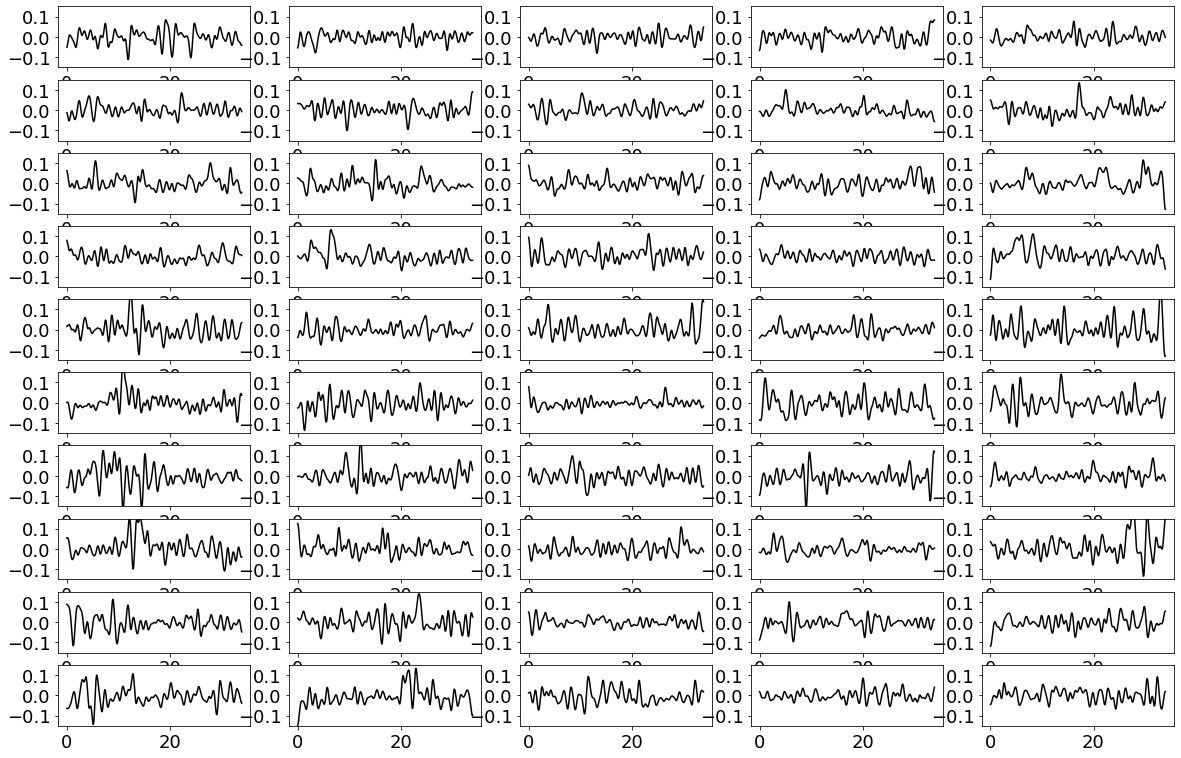

In [16]:
import matplotlib.pyplot as plt

frames = int(fs*(calc_end-calc_start))

plt.figure(figsize=(20, 24))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(pupil_velocity.shape[0]):
    plt.subplot(18, 5, ex+1)
    plt.plot(t[:frames-1], pupil_velocity[ex], color='black')
    #plt.axvspan(start_stim-calc_start, stop_stim-calc_start, color='red', alpha=0.3)
    plt.ylim(-0.15, 0.15)
    
plt.show()

In [17]:
window = int(fs*0.2)

#extracted_pupil = pupil_velocity[:, int(fs*learn_start)-look_frame:int(fs*learn_start)+frames]
extracted_pupil = pupil_velocity

binary_pupil = []
for ex in range(extracted_pupil.shape[0]):
    temp_p = []
    for f in range(extracted_pupil.shape[1]-window+1):
        if extracted_pupil[ex, f] > 0.07:
            temp_p.append(1)
        else:
            temp_p.append(0)
    binary_pupil.append(temp_p)

binary_pupil = np.array(binary_pupil)
print(binary_pupil.shape)

(50, 676)


In [18]:
Pupil_data = binary_pupil

In [19]:
ca_array = np.transpose(raw_signal)

print(raw_signal.shape)
print(ca_array.shape)

(26, 34000)
(34000, 26)


In [20]:
import numpy as np

# 300枚ずつのリストに分割する
batch_size = fs*(calc_end-calc_start)
pre_image_array = [ca_array[i:i+batch_size] for i in range(0, ca_array.shape[0], batch_size)]

pre_image_array = np.array(pre_image_array)
print(pre_image_array.shape)

(50, 680, 26)


In [21]:
image_array = []
for ex in range (pre_image_array.shape[0]):
    #image_array.append(pre_image_array[ex, fs*calc_start:fs*calc_end])
    #image_array.append(pre_image_array[ex, int(fs*learn_start)-look_frame-window+1:int(fs*learn_start)+frames])
    image_array.append(pre_image_array[ex, :-1])

image_array = np.array(image_array)

print(image_array.shape)

(50, 679, 26)


In [22]:
filtered_ca = []
for ex in range(image_array.shape[0]):
    x = []
    for i in range(image_array.shape[2]):
        raw_ratio = [row[i] for row in image_array[ex]]
        #filtered_array = signal_lowpass_filter(np.array(raw_ratio))
        filtered_array = moving_average(np.array(raw_ratio), window=window)
        filtered_ratio = filtered_array.tolist()
        x.append(filtered_ratio)
    filtered_ca.append(x)

filtered_ca = np.array(filtered_ca)
filtered_ca = filtered_ca.transpose(0, 2, 1)

print(filtered_ca.shape)

(50, 676, 26)


In [23]:
signal = filtered_ca.transpose(0, 2, 1)
print(signal.shape)

(50, 26, 676)


In [24]:
TEratio_Ca   = signal
TEPupil_data = Pupil_data

In [25]:
TEST = list(range(TEratio_Ca.shape[0]))
print(len(TEST))

50


In [26]:
signal_min = np.load(f"{rnn_folder}/shap{shap_number}/{date}_{shap_number}_train_signal_min.npy")
signal_max = np.load(f"{rnn_folder}/shap{shap_number}/{date}_{shap_number}_train_signal_max.npy")
signal_ave = np.load(f"{rnn_folder}/shap{shap_number}/{date}_{shap_number}_train_signal_ave.npy")
signal_std = np.load(f"{rnn_folder}/shap{shap_number}/{date}_{shap_number}_train_signal_std.npy")

In [27]:
import numpy

targetframe = 0 # n frame later label you rely on

def mini_max_signal_a(dataset):
    dataset_nor = []
    for i in range(len(dataset)):
        min_value = signal_min[i]
        max_value = signal_max[i]
        dataset_ex = []
        for t in range(len(dataset[i])-targetframe):
            if (max_value - min_value)>0:
                dataset_ex.append((dataset[i][t] - min_value) / (max_value - min_value))
            if (max_value - min_value)==0:
                dataset_ex.append(0)

        dataset_nor.append(dataset_ex)
    
    return dataset_nor

def mini_max_signal_b(dataset):
    dataset_nor = []
    for i in range(len(dataset)):
        min_value = signal_min[i]
        max_value = signal_max[i]
        dataset_ex = []
        for t in range(len(dataset[i])-abs(targetframe)):
            if (max_value - min_value)>0:
                dataset_ex.append((dataset[i][t+abs(targetframe)] - min_value) / (max_value - min_value))
            if (max_value - min_value)==0:
                dataset_ex.append(0)

        dataset_nor.append(dataset_ex)
    
    return dataset_nor

def z_score_signal(dataset):
    dataset_nor = []
    for i in range(len(dataset)):
        ave_value = signal_ave[i]
        std_value = signal_std[i]
        dataset_ex = []
        for t in range(len(dataset[i])-targetframe):
            dataset_ex.append((dataset[i][t] - ave_value) / std_value)
        dataset_nor.append(dataset_ex)
    
    return dataset_nor

In [28]:
# Create input data [-n,n+1]
def create_dataset(dataset, look_frame):
    dataX, dataY = [], []
    #for i in range(look_frame,len(dataset)-(look_frame)):
    for i in range(look_frame, len(dataset)):
        xset = []
        for j in range(dataset.shape[1]-1):
            #a = dataset[(i-look_frame):(i+look_frame+1), j]
            a = dataset[(i-look_frame):(i+1), j]
            xset.append(a)
        dataY.append(dataset[i, -1])      
        dataX.append(xset)
    return numpy.array(dataX), numpy.array(dataY)

In [29]:
def Data_preprocess(signal, pupil):
    if targetframe >= 0:
        #signal = mini_max_signal_a(signal)
        signal = z_score_signal(signal)
        signal = numpy.array(signal).transpose()
        pupil = [[x] for x in numpy.array(pupil)]
        moved_pupil = pupil.copy()
        del moved_pupil[:targetframe]
    else:
        #signal = mini_max_signal_b(signal)
        signal = z_score_signal(signal)
        signal = numpy.array(signal).transpose()
        pupil = [[x] for x in numpy.array(pupil)]
        moved_pupil = pupil.copy()
        del moved_pupil[targetframe:]
    pupil =  numpy.array(moved_pupil)
    #pupil =  (pupil - pupil_min) / (pupil_max - pupil_min)
    #pupil =  (pupil - pupil_ave) / pupil_std
    # Label proportion
    print('The positive proportion is {:.2f}'.format(pupil.sum() / len(pupil)))
    # Create dataset
    dataset = numpy.hstack([signal.astype('float32'), pupil.astype('float32')])
    X, Y = create_dataset(dataset, look_frame)
    return X, Y

In [30]:
# Training dataset
testX = numpy.empty([0, signal.shape[1], look_frame+1], dtype=numpy.float32)
testY = numpy.empty(0, dtype=numpy.float32)
for i in TEST:
    X, Y = Data_preprocess(TEratio_Ca[i], TEPupil_data[i])
    testX = numpy.concatenate([testX, X], axis=0)
    testY = numpy.concatenate([testY, Y], axis=0)

The positive proportion is 0.01
The positive proportion is 0.00
The positive proportion is 0.00
The positive proportion is 0.02
The positive proportion is 0.01
The positive proportion is 0.01
The positive proportion is 0.00
The positive proportion is 0.01
The positive proportion is 0.02
The positive proportion is 0.02
The positive proportion is 0.04
The positive proportion is 0.04
The positive proportion is 0.01
The positive proportion is 0.03
The positive proportion is 0.06
The positive proportion is 0.00
The positive proportion is 0.04
The positive proportion is 0.04
The positive proportion is 0.00
The positive proportion is 0.07
The positive proportion is 0.05
The positive proportion is 0.01
The positive proportion is 0.05
The positive proportion is 0.01
The positive proportion is 0.09
The positive proportion is 0.04
The positive proportion is 0.02
The positive proportion is 0.01
The positive proportion is 0.04
The positive proportion is 0.07
The positive proportion is 0.06
The posi

In [31]:
print(testX.shape)
print(testY.shape)

(33300, 26, 11)
(33300,)


In [32]:
input_test = testX.transpose(0,2,1)
print(input_test.shape)

(33300, 11, 26)


In [33]:
corrected_start_stim = 15
corrected_stop_stim = corrected_start_stim + (stop_stim - start_stim)

In [34]:
# Callback Setting
model_file_path = f"{rnn_folder}/shap{shap_number}/{date}_{shap_number}_best_model_{ver}.h5"

In [35]:
model = load_model(model_file_path)

In [36]:
# Calcurate accuracy
model.evaluate(input_test,testY)

33300/33300 [==============================] - 9s 281us/sample - loss: 0.4732 - acc: 0.8044


[0.4731522772297845, 0.8044144]

In [37]:
# Predict
test_pred = model.predict(input_test)
test_target = testY

In [38]:
#prediction_frames = 30 - look_frame
prediction_frames = 660
print(prediction_frames)

660


In [39]:
# 初期値
start_value = 0.0 + (look_frame/fs)

# 増加量
increment = 1/fs

# 繰り返し回数
count = prediction_frames

# リストを生成
t = [start_value + i * increment for i in range(count)]

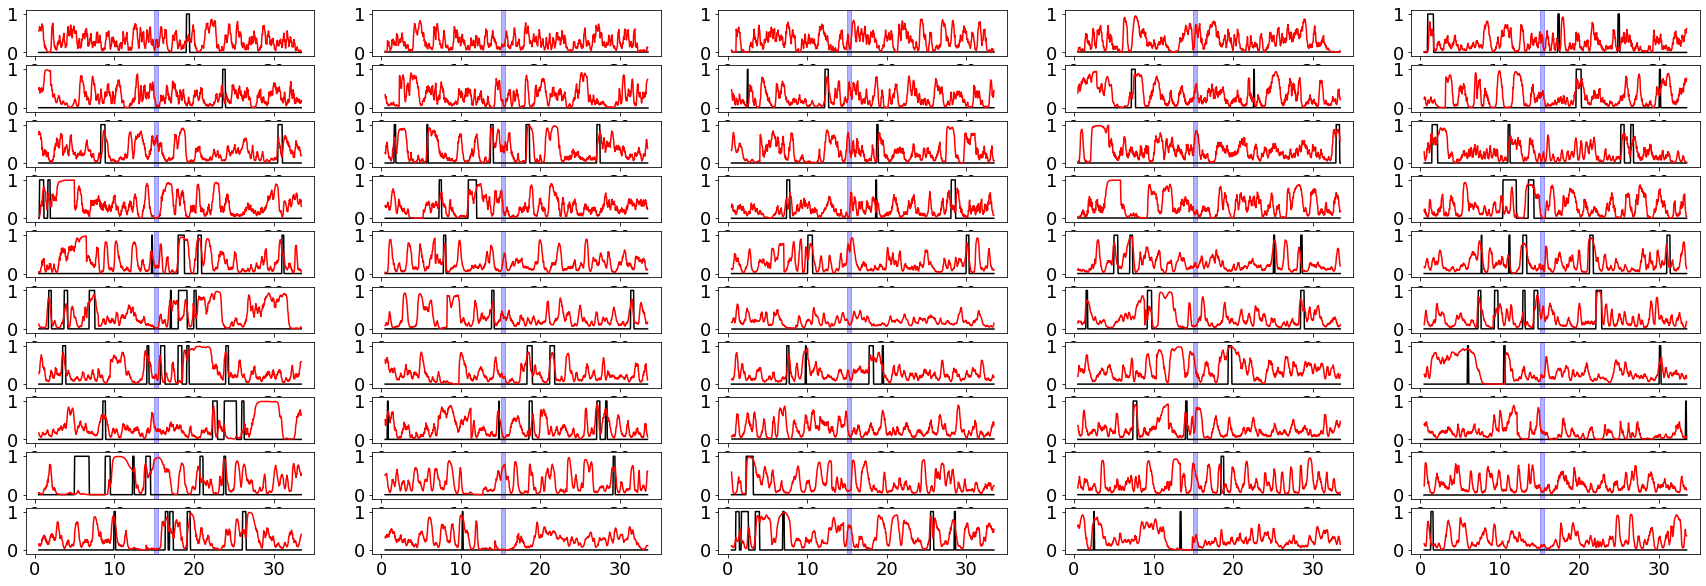

In [40]:
plt.figure(figsize=(30, 10))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(10, 5, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, test_pred[ex*prediction_frames:(ex+1)*prediction_frames, 0], color='red')
    plt.axvspan(corrected_start_stim, corrected_stop_stim, color='blue', alpha=0.3)
    plt.ylim(-0.1, 1.1)
    
plt.show()

In [41]:
classified_test_pred = []
for f in range(test_pred.shape[0]):
    if test_pred[f, 0] > 0.5:
        classified_test_pred.append(1)
    else:
        classified_test_pred.append(0)

classified_test_pred = np.array(classified_test_pred)
print(classified_test_pred.shape)

(33300,)


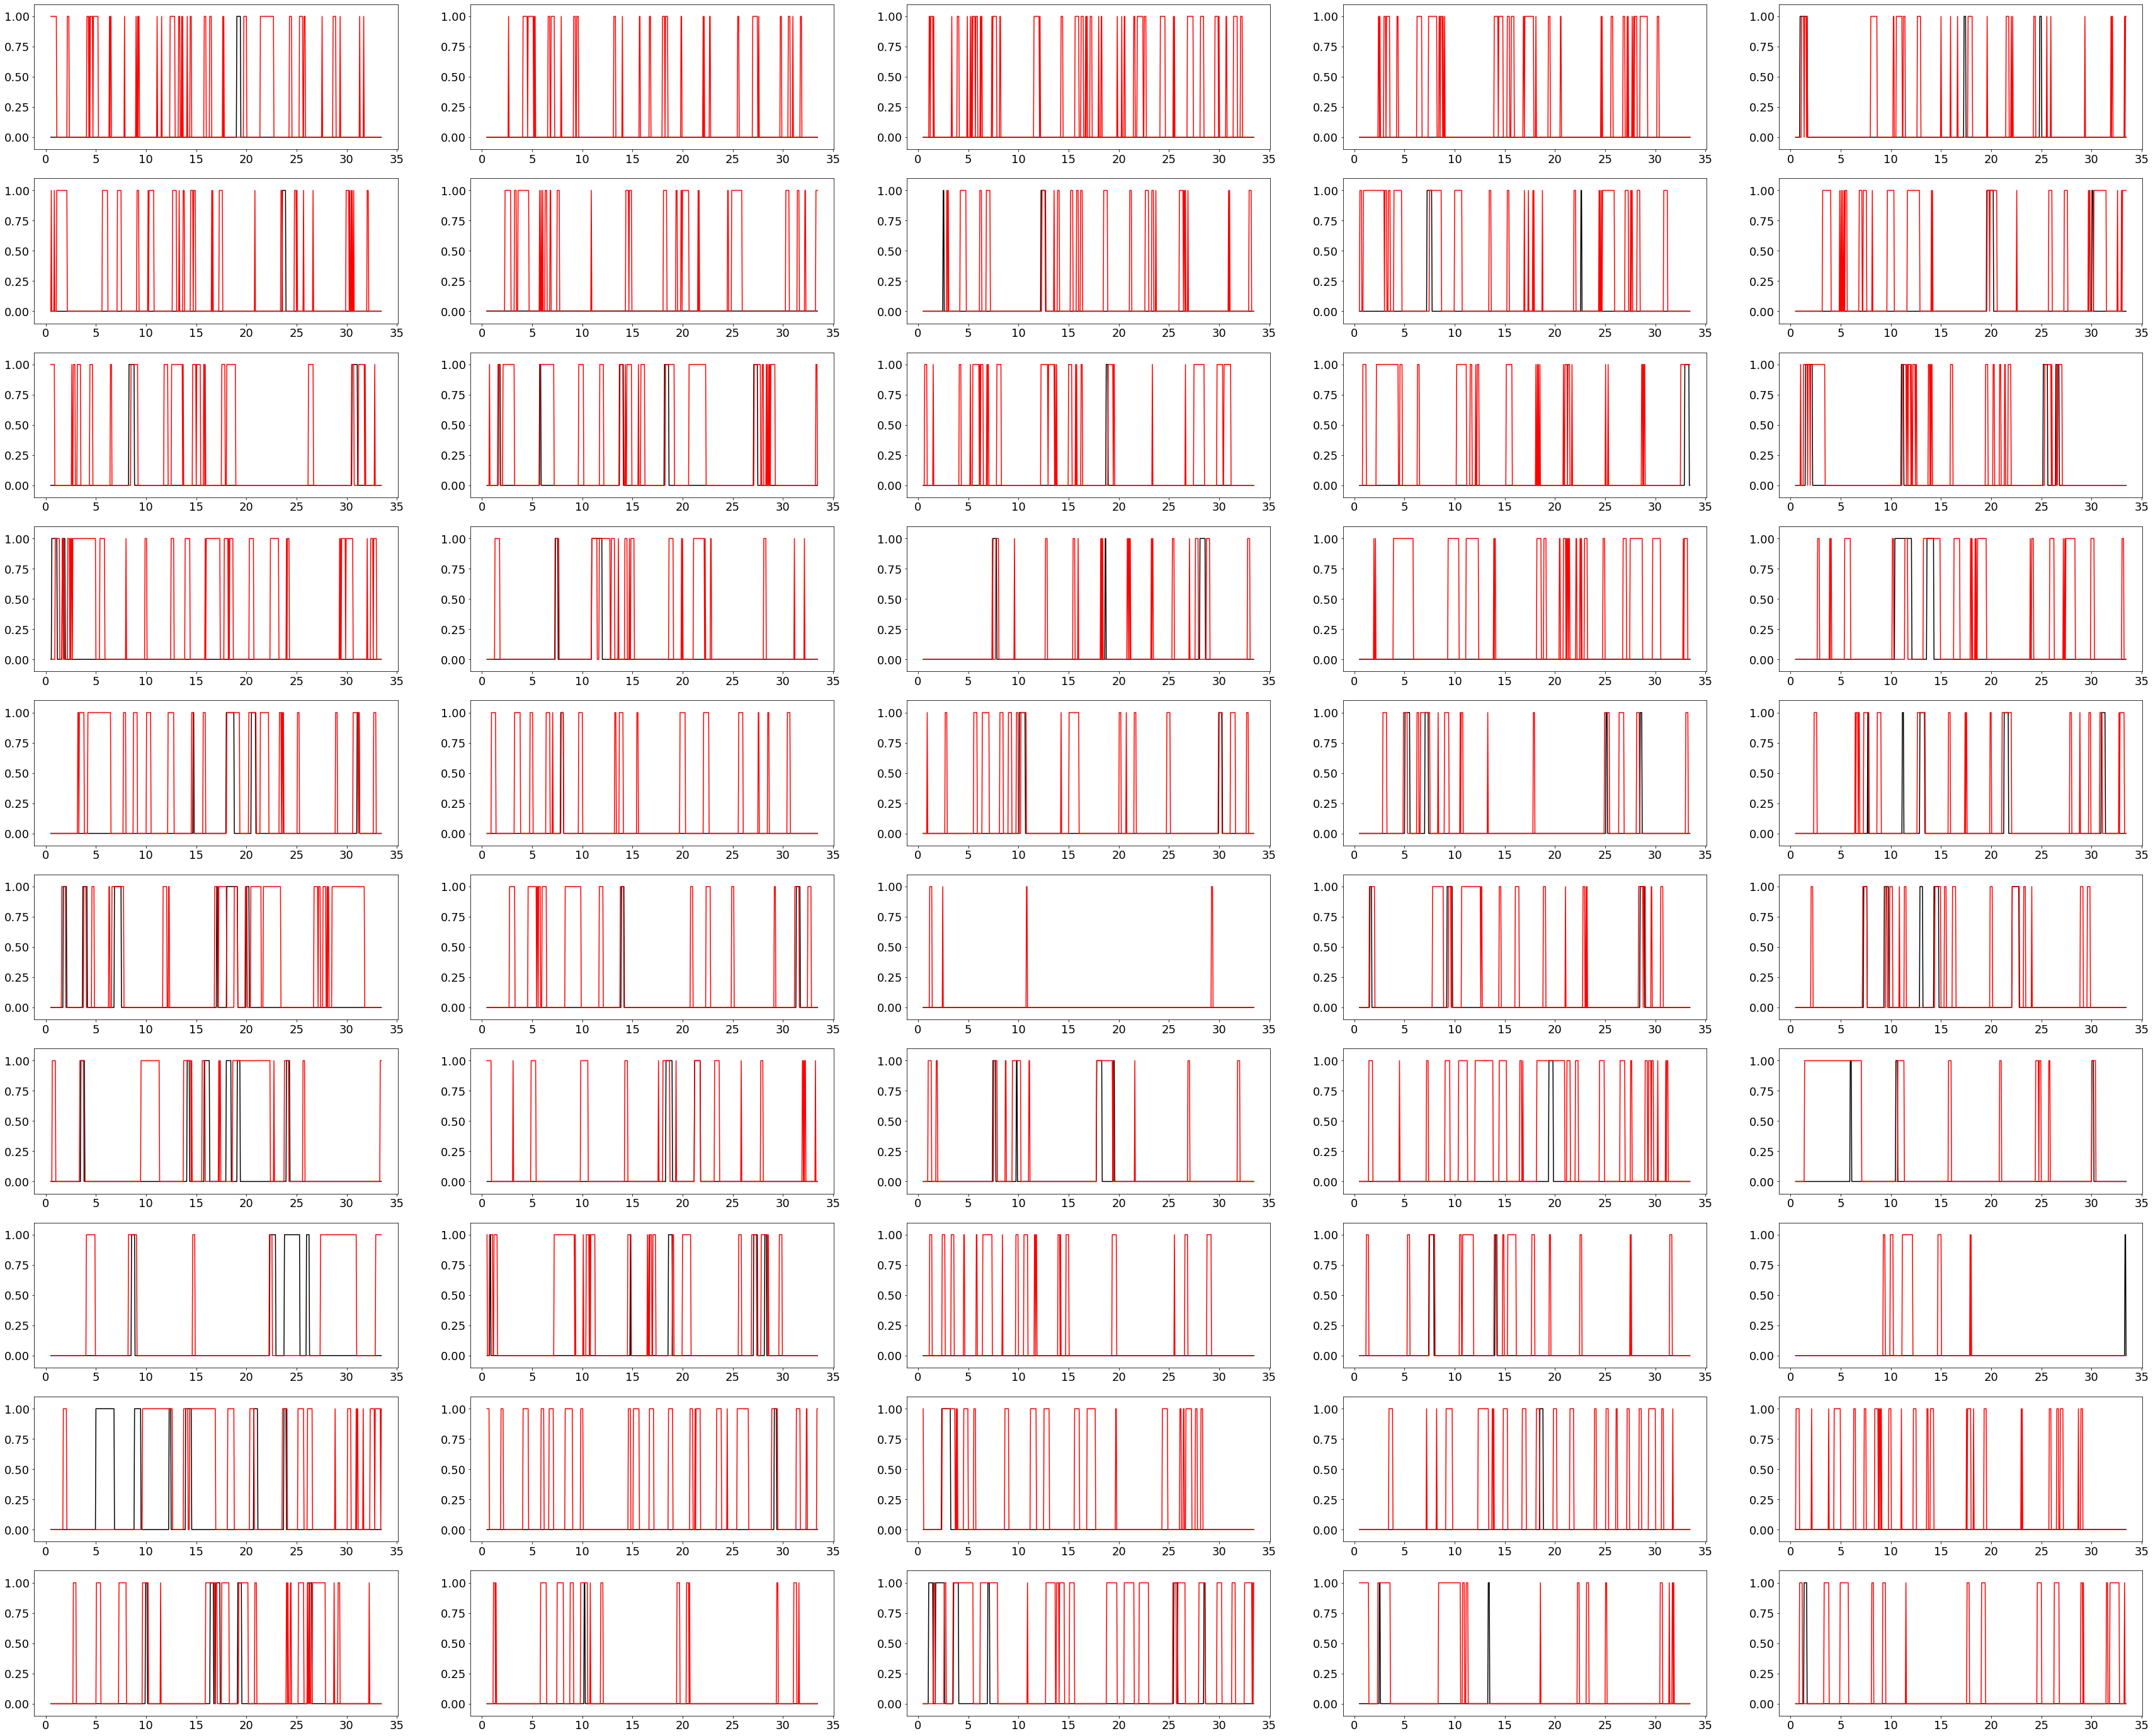

In [42]:
plt.figure(figsize=(60, 50))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(10, 5, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_test_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    #plt.axvspan(corrected_start_stim, corrected_stop_stim, color='blue', alpha=0.3)
    plt.ylim(-0.1, 1.1)
    
plt.show()

In [43]:
np.save(f"{rnn_folder}/shap{shap_number}/{date}_{shap_number}_truth_test_NoStim.npy", test_target)
np.save(f"{rnn_folder}/shap{shap_number}/{date}_{shap_number}_prediction_test_NoStim.npy", test_pred)

In [44]:
# Plot ROC curve
def plot_roc(y_pred, y_test, mode):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred, pos_label=1)
    AUC = roc_auc_score(y_test, y_pred)
    plt.plot(fpr, tpr, label="AUC = {:.3f}".format(AUC))
    plt.title(mode + " ROC curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()
    print('AUC: {:.3f}'.format(AUC))
    opt_thr = thresholds[numpy.argmax(tpr - fpr)]
    print('Optimal threshold: {:.3f}'.format(opt_thr))
    return fpr, tpr

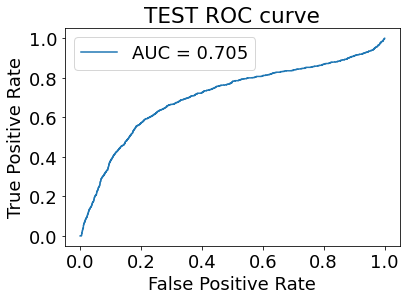

AUC: 0.705
Optimal threshold: 0.461


In [45]:
test_fpr, test_tpr   = plot_roc(test_pred, test_target, "TEST")